# Simulation-Based Inference for an Adaptive-Network Epidemic Model

**ST3247 Project — Sections 1–3 (Basic ABC + Summary Statistics)**

Scope:
1. Observed-data structure
2. Summary-statistic design and sensitivity
3. Rejection ABC on pseudo-observed and real data
4. Posterior diagnostics and posterior predictive checks

Advanced methods (SMC-ABC and regression adjustment) are documented in the companion notebook.

## 0. Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, gaussian_kde

from updated_simulator import simulate         

rng_global = np.random.default_rng(42)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
PALETTE = sns.color_palette("Dark2")


## 1. Observed Data

We observe $R=40$ independent epidemic realizations generated by one latent $(\beta,\gamma,\rho)$ triplet. Available channels:

| File | Content |
|------|---------|
| `infected_timeseries.csv` | Infected fraction over $T=200$ time steps |
| `rewiring_timeseries.csv` | Rewiring counts per step |
| `final_degree_histograms.csv` | Degree histogram at $t=T$ |

Visualization uses all replicate traces (low opacity), plus median and 10th-90th bands to reduce sensitivity to right-tail trajectories.

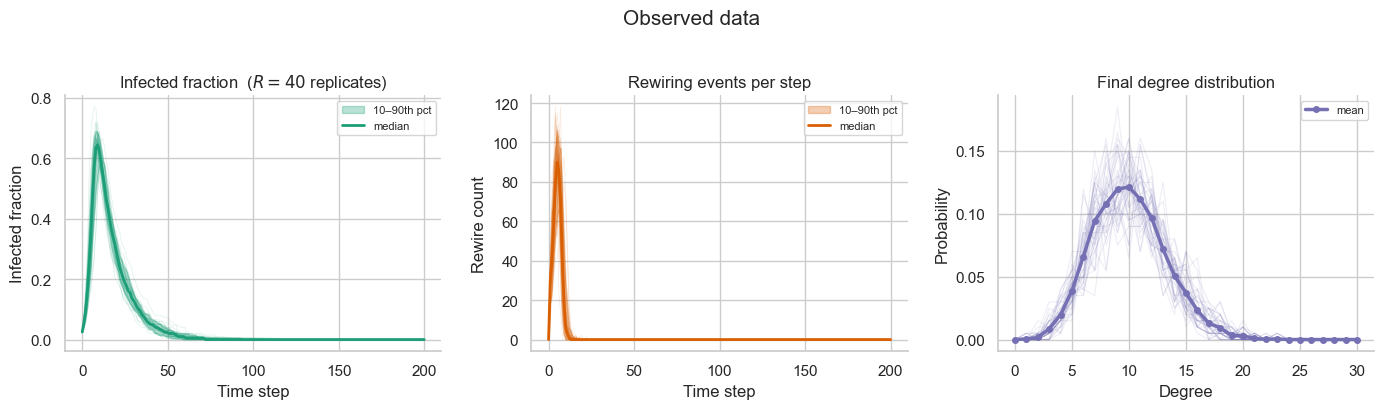

In [ ]:
infected_obs = pd.read_csv("data/infected_timeseries.csv")
rewire_obs   = pd.read_csv("data/rewiring_timeseries.csv")
degree_obs   = pd.read_csv("data/final_degree_histograms.csv")

# time x replicate matrices
inf_wide = infected_obs.pivot(index="time", columns="replicate_id", values="infected_fraction")
rew_wide = rewire_obs.pivot(  index="time", columns="replicate_id", values="rewire_count")

t = inf_wide.index.values

# replicate-wise percentile summaries
def pct_summary(wide):
    return (wide.quantile(0.10, axis=1),
            wide.quantile(0.50, axis=1),
            wide.quantile(0.90, axis=1))

inf_lo, inf_med, inf_hi = pct_summary(inf_wide)
rew_lo, rew_med, rew_hi = pct_summary(rew_wide)

# mean final-degree histogram across replicates
deg_mean = (degree_obs.groupby("degree")["count"]
                       .mean()
                       .reindex(range(31), fill_value=0))

# three-panel observed-data overview
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# panel 1: infected-fraction traces and envelope
ax = axes[0]
for col in inf_wide.columns:
    ax.plot(t, inf_wide[col].values, color=PALETTE[0], alpha=0.12, lw=0.6)
ax.fill_between(t, inf_lo, inf_hi, color=PALETTE[0], alpha=0.30, label="10–90th pct")
ax.plot(t, inf_med, color=PALETTE[0], lw=2.0, label="median")
ax.set(xlabel="Time step", ylabel="Infected fraction", title="Infected fraction  ($R=40$ replicates)")
ax.legend(fontsize=8)

# panel 2: rewiring traces and envelope
ax = axes[1]
for col in rew_wide.columns:
    ax.plot(t, rew_wide[col].values, color=PALETTE[1], alpha=0.12, lw=0.6)
ax.fill_between(t, rew_lo, rew_hi, color=PALETTE[1], alpha=0.30, label="10–90th pct")
ax.plot(t, rew_med, color=PALETTE[1], lw=2.0, label="median")
ax.set(xlabel="Time step", ylabel="Rewire count", title="Rewiring events per step")
ax.legend(fontsize=8)

# panel 3: degree histograms by replicate plus mean
ax = axes[2]
for rep_id in degree_obs["replicate_id"].unique():
    d = (degree_obs[degree_obs["replicate_id"] == rep_id]
        .set_index("degree")["count"]
        .reindex(range(31), fill_value=0))
    ax.plot(d.index, d.values / d.sum(), color=PALETTE[2], alpha=0.12, lw=0.8)
obs_deg_prob = deg_mean / deg_mean.sum()
ax.plot(obs_deg_prob.index, obs_deg_prob.values, color=PALETTE[2], lw=2.5,
        marker="o", ms=4, label="mean")
ax.set(xlabel="Degree", ylabel="Probability", title="Final degree distribution")
ax.legend(fontsize=8)

plt.suptitle("Observed data", y=1.02, fontsize=15)
sns.despine()
plt.tight_layout()
plt.show()


## 2. Simulator Sanity Check

Before ABC, verify output shape and parameter sensitivity partition:

- Infected fraction mainly identifies the transmission-recovery balance ($\beta/\gamma$).
- Rewiring counts primarily encode adaptive response intensity ($\rho$).
- Final degree structure adds complementary information on rewiring effects.

This motivates a multi-channel summary vector.

In [3]:
rng_test = np.random.default_rng(0)
inf_t, rew_t, deg_t = simulate(beta=0.25, gamma=0.10, rho=0.4, rng=rng_test)

print(f"infected shape : {inf_t.shape}  (T+1 = 201 steps)")
print(f"rewire shape   : {rew_t.shape}")
print(f"degree shape   : {deg_t.shape}  (degrees 0..30 = 31 bins)")
print(f"peak fraction  : {inf_t.max():.3f}  at t={inf_t.argmax()}")
print(f"total rewires  : {rew_t.sum():.0f}")
print(f"mean degree    : {(np.arange(31) * deg_t / deg_t.sum()).sum():.2f}")


infected shape : (201,)  (T+1 = 201 steps)
rewire shape   : (201,)
degree shape   : (31,)  (degrees 0..30 = 31 bins)
peak fraction  : 0.665  at t=7
total rewires  : 469
mean degree    : 9.34


## 3. Summary Statistics

### Rationale

We retain summaries that are interpretable, parameter-sensitive, and non-redundant under prior simulation diagnostics. `mean_degree` is excluded from distance calculations due to near-constant behavior and negligible rank correlation with all parameters.

Core identifiability point: $\beta$ and $\rho$ can produce similar prevalence trajectories, so rewiring and degree-structure summaries are required to break this confounding.

In [ ]:
def calc_summaries(infected_fraction, rewire_counts, degree_histogram):
    """Return engineered summary vector aligned with SUMMARY_NAMES."""

    I = infected_fraction
    Rw = rewire_counts
    T = len(I)

    # core epidemic summaries
    peak = np.max(I)
    t_peak = np.argmax(I)
    auc = np.sum(I)

    early_mass = np.sum(I[: max(1, T // 5)])

    # threshold-crossing times
    def first_crossing(arr, thresh):
        idx = np.where(arr >= thresh)[0]
        return idx[0] if len(idx) > 0 else T

    t_5  = first_crossing(I, 0.05)
    t_10 = first_crossing(I, 0.10)
    t_20 = first_crossing(I, 0.20)

    duration_10 = np.sum(I >= 0.10)

    # incidence proxy from prevalence increments
    dI = np.diff(I, prepend=I[0])
    incidence = np.maximum(dI, 0)

    inc_peak = np.max(incidence)
    t_inc_peak = np.argmax(incidence)

    # growth and post-peak decay slopes
    eps = 1e-8

    t_growth_end = max(2, T // 5)
    x = np.arange(t_growth_end)
    y = np.log(I[:t_growth_end] + eps)
    slope_growth = np.polyfit(x, y, 1)[0]

    if t_peak < T - 2:
        x2 = np.arange(t_peak, T)
        y2 = np.log(I[t_peak:] + eps)
        slope_decay = np.polyfit(x2, y2, 1)[0]
    else:
        slope_decay = 0.0

    # rewiring summaries
    total_rewire = np.sum(Rw)
    max_rewire = np.max(Rw)
    t_rewire_peak = np.argmax(Rw)

    early_rewire = np.sum(Rw[: max(1, T // 5)])

    # infection-rewiring coupling summaries
    lag_rewire_infect = t_rewire_peak - t_peak

    rewire_to_auc = total_rewire / (auc + eps)

    # robust correlations
    if np.std(I) > 0 and np.std(Rw) > 0:
        corr_I_R = np.corrcoef(I, Rw)[0, 1]
    else:
        corr_I_R = 0.0

    if np.std(incidence) > 0 and np.std(Rw) > 0:
        corr_dI_R = np.corrcoef(incidence, Rw)[0, 1]
    else:
        corr_dI_R = 0.0

    # degree-distribution summaries
    degrees = np.repeat(np.arange(len(degree_histogram)), degree_histogram)

    mean_degree = np.mean(degrees) if len(degrees) > 0 else 0.0
    var_degree  = np.var(degrees)  if len(degrees) > 0 else 0.0

    p = degree_histogram / (np.sum(degree_histogram) + eps)
    entropy_degree = -np.sum(p * np.log(p + eps))

    tail_mass = np.sum(degree_histogram[10:]) / (np.sum(degree_histogram) + eps)

    return np.array([
        peak,
        t_peak,
        auc,
        early_mass,

        t_5,
        t_10,
        t_20,
        duration_10,

        inc_peak,
        t_inc_peak,

        slope_growth,
        slope_decay,

        total_rewire,
        max_rewire,
        t_rewire_peak,
        early_rewire,

        lag_rewire_infect,
        rewire_to_auc,
        corr_I_R,
        corr_dI_R,

        mean_degree,
        var_degree,
        entropy_degree,
        tail_mass,
    ], dtype=float)

In [ ]:
SUMMARY_NAMES = [
    "peak",
    "t_peak",
    "auc",
    "early_mass",

    "t_5",
    "t_10",
    "t_20",
    "duration_10",

    "inc_peak",
    "t_inc_peak",

    "slope_growth",
    "slope_decay",

    "total_rewire",
    "max_rewire",
    "t_rewire_peak",
    "early_rewire",

    "lag_rewire_infect",
    "rewire_to_auc",
    "corr_I_R",
    "corr_dI_R",

    "mean_degree",
    "var_degree",
    "entropy_degree",
    "tail_mass",
]

# quick sanity check
rng_chk = np.random.default_rng(1)
inf_c, rew_c, deg_c = simulate(beta=0.2, gamma=0.10, rho=0.4, rng=rng_chk)
s_chk = calc_summaries(inf_c, rew_c, deg_c)
for name, val in zip(SUMMARY_NAMES, s_chk):
    print(f"  {name:<24} {val:.4f}")


  peak                     0.6100
  t_peak                   9.0000
  auc                      9.8150
  early_mass               9.3200
  t_5                      1.0000
  t_10                     2.0000
  t_20                     4.0000
  duration_10              27.0000
  inc_peak                 0.1450
  t_inc_peak               5.0000
  slope_growth             -0.0533
  slope_decay              -0.1162
  total_rewire             545.0000
  max_rewire               125.0000
  t_rewire_peak            5.0000
  early_rewire             545.0000
  lag_rewire_infect        -4.0000
  rewire_to_auc            55.5273
  corr_I_R                 0.4612
  corr_dI_R                0.9945
  mean_degree              9.8600
  var_degree               11.8504
  entropy_degree           2.5604
  tail_mass                0.5050


In [6]:
PRIOR_BETA = (0.05, 0.50)
PRIOR_GAMMA = (0.02, 0.20)
PRIOR_RHO = (0.00, 0.80)

def sample_prior_theta(rng):
    return np.array([
        rng.uniform(*PRIOR_BETA),
        rng.uniform(*PRIOR_GAMMA),
        rng.uniform(*PRIOR_RHO),
    ], dtype=float)

def simulate_one_summary(theta, rng):
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
    return calc_summaries(inf, rew, deg)

def simulate_mean_summary(theta, n_reps, rng):
    out = np.empty((n_reps, len(SUMMARY_NAMES)), dtype=float)
    for r in range(n_reps):
        out[r] = simulate_one_summary(theta, rng)
    return out.mean(axis=0)

def generate_prior_bank(n_sim, rng, n_reps_per_theta=1, chunk_size=2000, verbose=True):
    params = np.empty((n_sim, 3), dtype=float)
    sims   = np.empty((n_sim, len(SUMMARY_NAMES)), dtype=float)

    n_chunks = (n_sim + chunk_size - 1) // chunk_size

    for chunk in range(n_chunks):
        start = chunk * chunk_size
        stop  = min((chunk + 1) * chunk_size, n_sim)

        for i in range(start, stop):
            theta = sample_prior_theta(rng)
            params[i] = theta
            sims[i] = simulate_mean_summary(theta, n_reps=n_reps_per_theta, rng=rng)

        if verbose:
            print(f"  completed {stop:,}/{n_sim:,}", flush=True)

    return params, sims

### 3.1 Observed Summary Vector

Replicate-level summaries are averaged across the 40 observed runs.

In [8]:
def load_observed_summaries(infected_df, rewire_df, degree_df):
    """Return mean summary vector across all replicates in the observed data."""
    rep_summaries = []
    for rep_id in infected_df["replicate_id"].unique():
        inf = infected_df[infected_df["replicate_id"] == rep_id]["infected_fraction"].values
        rew = rewire_df  [rewire_df  ["replicate_id"] == rep_id]["rewire_count"].values
        deg_rows = degree_df[degree_df["replicate_id"] == rep_id]
        deg = (deg_rows.set_index("degree")["count"]
                       .reindex(range(31), fill_value=0).values)
        rep_summaries.append(calc_summaries(inf, rew, deg))
    return np.mean(rep_summaries, axis=0)

s_obs = load_observed_summaries(infected_obs, rewire_obs, degree_obs)
print("Observed summary vector:")
for name, val in zip(SUMMARY_NAMES, s_obs):
    print(f"  {name:<20} {val:.4f}")


Observed summary vector:
  peak                 0.6571
  t_peak               8.7500
  auc                  11.3990
  early_mass           10.7280
  t_5                  1.2250
  t_10                 2.5750
  t_20                 4.0750
  duration_10          31.1750
  inc_peak             0.1334
  t_inc_peak           6.2250
  slope_growth         -0.0318
  slope_decay          -0.1095
  total_rewire         545.1500
  max_rewire           98.1250
  t_rewire_peak        5.5000
  early_rewire         545.1500
  lag_rewire_infect    -3.2500
  rewire_to_auc        48.0936
  corr_I_R             0.4648
  corr_dI_R            0.9659
  mean_degree          10.0172
  var_degree           10.3410
  entropy_degree       2.5233
  tail_mass            0.5424


## 4. Prior Simulations

We sample $N=100000$ parameter draws from the joint uniform prior and simulate one realization per draw. This offline bank dominates compute cost and enables fast downstream ABC thresholding.

In [25]:
N_SIM = 100_000
R_SIM_PER_THETA = 1
CHUNK_SIZE = 2_000

rng_prior = np.random.default_rng(7)

print(f"Running {N_SIM:,} prior simulations "
    f"(R_SIM_PER_THETA={R_SIM_PER_THETA}, chunk_size={CHUNK_SIZE}) ...", flush=True)

t0 = time.perf_counter()

params_prior, sims_prior = generate_prior_bank(
    n_sim=N_SIM,
    rng=rng_prior,
    n_reps_per_theta=R_SIM_PER_THETA,
    chunk_size=CHUNK_SIZE,
    verbose=True,
)

t1 = time.perf_counter()

print(f"\nDone in {t1 - t0:.2f} seconds.")
print("params_prior shape:", params_prior.shape)
print("sims_prior shape:  ", sims_prior.shape)
print(f"Throughput: {N_SIM / (t1 - t0):.1f} parameter draws/sec")

Running 100,000 prior simulations (R_SIM_PER_THETA=1, chunk_size=2000) ...
  completed 2,000/100,000
  completed 4,000/100,000
  completed 6,000/100,000
  completed 8,000/100,000
  completed 10,000/100,000
  completed 12,000/100,000
  completed 14,000/100,000
  completed 16,000/100,000
  completed 18,000/100,000
  completed 20,000/100,000
  completed 22,000/100,000
  completed 24,000/100,000
  completed 26,000/100,000
  completed 28,000/100,000
  completed 30,000/100,000
  completed 32,000/100,000
  completed 34,000/100,000
  completed 36,000/100,000
  completed 38,000/100,000
  completed 40,000/100,000
  completed 42,000/100,000
  completed 44,000/100,000
  completed 46,000/100,000
  completed 48,000/100,000
  completed 50,000/100,000
  completed 52,000/100,000
  completed 54,000/100,000
  completed 56,000/100,000
  completed 58,000/100,000
  completed 60,000/100,000
  completed 62,000/100,000
  completed 64,000/100,000
  completed 66,000/100,000
  completed 68,000/100,000
  completed

### 4.1 Normalization

Each summary is scaled by its prior standard deviation before Euclidean distance evaluation. This prevents high-magnitude statistics from dominating acceptance.

Diagnostic note: `mean_degree` inflates after scaling because its prior variance is very small, reinforcing its exclusion.

In [ ]:
s_std = sims_prior.std(axis=0)
s_std[s_std == 0] = 1.0 # guard zero-variance columns

sims_norm  = sims_prior / s_std
s_obs_norm = s_obs      / s_std

print("Per-statistic std and normalised observed value:")
print(f"  {'statistic':<20} {'prior std':>10} {'obs (raw)':>10} {'obs (norm)':>10}")
print("  " + "-" * 54)
for name, std, raw, norm in zip(SUMMARY_NAMES, s_std, s_obs, s_obs_norm):
    flag = " ← excluded" if name == "mean_degree" else ""
    print(f"  {name:<20} {std:>10.4f} {raw:>10.4f} {norm:>10.4f}{flag}")


Per-statistic std and normalised observed value:
  statistic             prior std  obs (raw) obs (norm)
  ------------------------------------------------------
  peak                     0.2574     0.6571     2.5527
  t_peak                   4.6923     8.7500     1.8648
  auc                      9.5516    11.3990     1.1934
  early_mass               6.0613    10.7280     1.7699
  t_5                     38.6588     1.2250     0.0317
  t_10                    61.5130     2.5750     0.0419
  t_20                    69.2877     4.0750     0.0588
  duration_10             23.2652    31.1750     1.3400
  inc_peak                 0.1073     0.1334     1.2426
  t_inc_peak               3.6826     6.2250     1.6904
  slope_growth             0.1878    -0.0318    -0.1694
  slope_decay              0.0302    -0.1095    -3.6310
  total_rewire           351.0715   545.1500     1.5528
  max_rewire              66.4302    98.1250     1.4771
  t_rewire_peak            3.7978     5.5000     1.448

### 4.2 Summary-Statistic Sensitivity

Spearman rank correlations between summaries and parameters under prior draws provide a pre-data informativeness screen. Summaries with weak signal across all parameters are deprioritized.

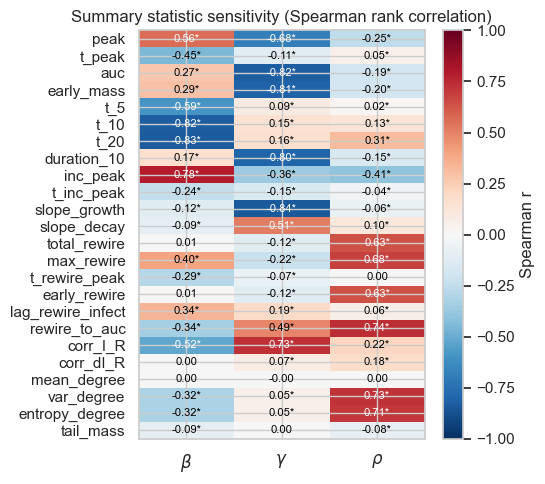


Note: mean_degree has |r| < 0.05 for all parameters — excluded from distance.


In [27]:
PARAM_NAMES = ["beta", "gamma", "rho"]
n_stats  = len(SUMMARY_NAMES)
n_params = len(PARAM_NAMES)

corr_mat = np.zeros((n_stats, n_params))
pval_mat = np.zeros((n_stats, n_params))

for i in range(n_stats):
    for j in range(n_params):
        r, p = spearmanr(sims_prior[:, i], params_prior[:, j])
        corr_mat[i, j] = r
        pval_mat[i, j] = p

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(n_params))
ax.set_xticklabels([r"$\beta$", r"$\gamma$", r"$\rho$"], fontsize=12)
ax.set_yticks(range(n_stats))
ax.set_yticklabels(SUMMARY_NAMES)
plt.colorbar(im, ax=ax, label="Spearman r")
ax.set_title("Summary statistic sensitivity (Spearman rank correlation)")

for i in range(n_stats):
    for j in range(n_params):
        star = "*" if pval_mat[i, j] < 0.001 else ""
        col  = "white" if abs(corr_mat[i, j]) > 0.5 else "black"
        ax.text(j, i, f"{corr_mat[i,j]:.2f}{star}", ha="center", va="center",
                fontsize=8, color=col)

plt.tight_layout()
plt.show()

print("\nNote: mean_degree has |r| < 0.05 for all parameters — excluded from distance.")


The sensitivity map confirms a structural split: prevalence-shape summaries mostly load on $\beta,\gamma$, while rewiring and degree summaries load on $\rho$.

## 5. Screening Candidate Summaries (Entropy-First)

Selection uses two gates:

1. Entropy-based forward screening for posterior concentration.
2. Pseudo-observed NRMSE refinement on shortlisted subsets.

This balances compact search with out-of-sample recovery quality.

In [ ]:
def calc_distance(s_sim_norm, s_target_norm, stat_indices):
    """Euclidean distance on selected normalised summaries."""
    diff = s_sim_norm[:, stat_indices] - s_target_norm[stat_indices]
    return np.linalg.norm(diff, axis=1)


def abc_rejection(s_target_norm, sims_norm, params, stat_indices, acceptance_rate=0.05):
    """Rejection ABC for a chosen summary subset."""
    distances = calc_distance(sims_norm, s_target_norm, stat_indices)
    n_accept = max(1, int(acceptance_rate * len(params)))
    threshold = np.sort(distances)[n_accept]
    accepted = params[distances <= threshold]
    return accepted, threshold


def entropy_proxy_from_particles(particles, jitter=1e-12):
    """Log-determinant covariance proxy for posterior spread."""
    particles = np.asarray(particles, dtype=float)
    n = particles.shape[0]
    w = np.ones(n, dtype=float) / n
    cov = np.cov(particles, rowvar=False, aweights=w)
    cov = cov + jitter * np.eye(cov.shape[0])
    sign, logdet = np.linalg.slogdet(cov)
    return float(logdet) if sign > 0 else np.inf


# greedy forward screening by entropy on observed data
candidate_idx = [i for i, n in enumerate(SUMMARY_NAMES) if n != "mean_degree"]

selected = []
remaining = candidate_idx.copy()
entropy_rows = []

for k in range(1, len(candidate_idx) + 1):
    best_j = None
    best_entropy = np.inf

    for j in remaining:
        trial = selected + [j]
        acc, _ = abc_rejection(s_obs_norm, sims_norm, params_prior, trial, acceptance_rate=0.05)
        ent = entropy_proxy_from_particles(acc)

        if ent < best_entropy:
            best_entropy = ent
            best_j = j

    selected.append(best_j)
    remaining.remove(best_j)

    entropy_rows.append({
        "k": k,
        "added_idx": best_j,
        "added_name": SUMMARY_NAMES[best_j],
        "subset_idx": selected.copy(),
        "subset_names": [SUMMARY_NAMES[i] for i in selected],
        "entropy_proxy_logdet": best_entropy,
    })

entropy_path_df = pd.DataFrame(entropy_rows)
display(entropy_path_df.head(10))

,k,added_idx,added_name,subset_idx,subset_names,entropy_proxy_logdet
0,1,2,auc,[2],[auc],-17.307768
1,2,12,total_rewire,"[2, 12]","[auc, total_rewire]",-18.375555
2,3,3,early_mass,"[2, 12, 3]","[auc, total_rewire, early_mass]",-18.489663
3,4,10,slope_growth,"[2, 12, 3, 10]","[auc, total_rewire, early_mass, slope_growth]",-18.498101
4,5,6,t_20,"[2, 12, 3, 10, 6]","[auc, total_rewire, early_mass, slope_growth, ...",-18.501642
5,6,5,t_10,"[2, 12, 3, 10, 6, 5]","[auc, total_rewire, early_mass, slope_growth, ...",-18.502879
6,7,4,t_5,"[2, 12, 3, 10, 6, 5, 4]","[auc, total_rewire, early_mass, slope_growth, ...",-18.502995
7,8,17,rewire_to_auc,"[2, 12, 3, 10, 6, 5, 4, 17]","[auc, total_rewire, early_mass, slope_growth, ...",-18.497539
8,9,15,early_rewire,"[2, 12, 3, 10, 6, 5, 4, 17, 15]","[auc, total_rewire, early_mass, slope_growth, ...",-18.497439
9,10,18,corr_I_R,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18]","[auc, total_rewire, early_mass, slope_growth, ...",-18.532584


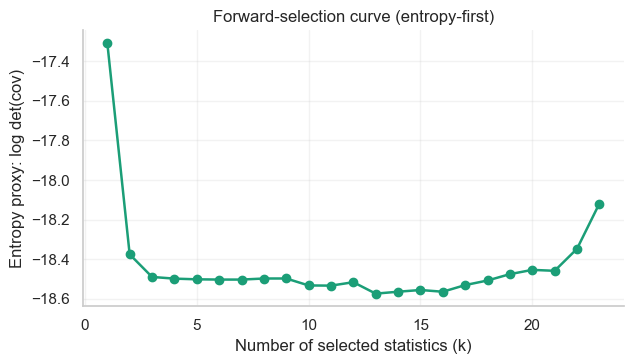

Best entropy rows:


,k,added_idx,added_name,subset_idx,subset_names,entropy_proxy_logdet
12,13,8,inc_peak,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8]","[auc, total_rewire, early_mass, slope_growth, ...",-18.573956
15,16,19,corr_dI_R,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",-18.564354
13,14,0,peak,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, 0]","[auc, total_rewire, early_mass, slope_growth, ...",-18.564264
14,15,1,t_peak,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",-18.555622
10,11,7,duration_10,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7]","[auc, total_rewire, early_mass, slope_growth, ...",-18.533487
9,10,18,corr_I_R,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18]","[auc, total_rewire, early_mass, slope_growth, ...",-18.532584
16,17,14,t_rewire_peak,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",-18.530737
11,12,13,max_rewire,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13]","[auc, total_rewire, early_mass, slope_growth, ...",-18.516221
17,18,21,var_degree,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",-18.507558
6,7,4,t_5,"[2, 12, 3, 10, 6, 5, 4]","[auc, total_rewire, early_mass, slope_growth, ...",-18.502995


In [29]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(entropy_path_df["k"], entropy_path_df["entropy_proxy_logdet"], marker="o", lw=1.8, color=PALETTE[0])
ax.set_xlabel("Number of selected statistics (k)")
ax.set_ylabel("Entropy proxy: log det(cov)")
ax.set_title("Forward-selection curve (entropy-first)")
ax.grid(alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

print("Best entropy rows:")
display(entropy_path_df.sort_values("entropy_proxy_logdet").head(10))

## 5. Summary-Subset Selection

### 5.1 Baseline Report Subsets

Two interpretable baselines are retained for benchmarking:

1. **infection_only**
2. **infection_rewiring**

The final primary subset (**final_joint**) is selected from the entropy-RMSE pipeline.

In [ ]:
INFECTION_ONLY = [0, 1, 3, 4, 8, 9, 10]

INFECTION_REWIRING = [0, 1, 3, 4, 8, 9, 10, 12, 13, 14, 15]

# final_joint is selected in the next cell via entropy + rmse

subset_name_table = pd.DataFrame({
    "subset": ["infection_only", "infection_rewiring"],
    "indices": [INFECTION_ONLY, INFECTION_REWIRING],
    "summary_names": [
        [SUMMARY_NAMES[i] for i in INFECTION_ONLY],
        [SUMMARY_NAMES[i] for i in INFECTION_REWIRING],
    ],
    "n_stats": [len(INFECTION_ONLY), len(INFECTION_REWIRING)],
})

display(subset_name_table)

,subset,indices,summary_names,n_stats
0,infection_only,"[0, 1, 3, 4, 8, 9, 10]","[peak, t_peak, early_mass, t_5, inc_peak, t_in...",7
1,infection_rewiring,"[0, 1, 3, 4, 8, 9, 10, 12, 13, 14, 15]","[peak, t_peak, early_mass, t_5, inc_peak, t_in...",11


In [ ]:
# 5.2 rmse refinement on entropy shortlist
prior_std = params_prior.std(axis=0)


def evaluate_subset_nrmse(idx, n_targets=20, r_target=10, alpha=0.05, seed=2027):
    rng = np.random.default_rng(seed)
    sq_errors = []

    for _ in range(n_targets):
        theta_true = sample_prior_theta(rng)
        s_target = simulate_mean_summary(theta_true, n_reps=r_target, rng=rng) / s_std

        acc, _ = abc_rejection(
            s_target,
            sims_norm,
            params_prior,
            idx,
            acceptance_rate=alpha,
        )

        if acc is None or len(acc) == 0:
            continue

        theta_hat = acc.mean(axis=0)
        sq_errors.append(((theta_hat - theta_true) / prior_std) ** 2)

    sq_errors = np.array(sq_errors)

    return {
        "n_targets_used": len(sq_errors),
        "nrmse_beta": np.sqrt(np.mean(sq_errors[:, 0])),
        "nrmse_gamma": np.sqrt(np.mean(sq_errors[:, 1])),
        "nrmse_rho": np.sqrt(np.mean(sq_errors[:, 2])),
        "nrmse_total": np.sqrt(np.mean(np.sum(sq_errors, axis=1))),
    }


# evaluate all subsets along the entropy-forward path
shortlist_rows = []
for _, row in entropy_path_df.iterrows():
    idx = row["subset_idx"]
    rmse = evaluate_subset_nrmse(idx, n_targets=20, r_target=10, alpha=0.05, seed=2027)

    shortlist_rows.append({
        "k": int(row["k"]),
        "subset_idx": idx,
        "subset_names": row["subset_names"],
        "n_stats": len(idx),
        "entropy_proxy_logdet": float(row["entropy_proxy_logdet"]),
        **rmse,
    })

shortlist_df = pd.DataFrame(shortlist_rows)

# choose best entropy under competitive rmse
rmse_best = shortlist_df["nrmse_total"].min()
shortlist_df["rmse_competitive"] = shortlist_df["nrmse_total"] <= 1.05 * rmse_best

eligible = shortlist_df[shortlist_df["rmse_competitive"]].copy()
best_row = eligible.sort_values("entropy_proxy_logdet").iloc[0]
FINAL_JOINT = list(best_row["subset_idx"])

# report-level subset set
SUBSETS = {
    "infection_only": INFECTION_ONLY,
    "infection_rewiring": INFECTION_REWIRING,
    "final_joint": FINAL_JOINT,
}

rows = []
for label, idx in SUBSETS.items():
    out = evaluate_subset_nrmse(idx, n_targets=20, r_target=10, alpha=0.05, seed=2027)
    rows.append({
        "subset": label,
        "n_stats": len(idx),
        "summary_names": [SUMMARY_NAMES[i] for i in idx],
        **out,
    })

subset_compare_df = pd.DataFrame(rows).sort_values("nrmse_total")

print("Chosen FINAL_JOINT from entropy-first + RMSE refinement:")
print(FINAL_JOINT)
print("\nShortlist decision table:")
display(shortlist_df.sort_values(["rmse_competitive", "entropy_proxy_logdet"], ascending=[False, True]).head(12))
print("\nReport comparison table:")
display(subset_compare_df)

Chosen FINAL_JOINT from entropy-first + RMSE refinement:
[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, 0, 1, 19]

Shortlist decision table:


,k,subset_idx,subset_names,n_stats,entropy_proxy_logdet,n_targets_used,nrmse_beta,nrmse_gamma,nrmse_rho,nrmse_total,rmse_competitive
15,16,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",16,-18.564354,20,0.311195,0.349390,0.384558,0.605641,True
14,15,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",15,-18.555622,20,0.310024,0.363348,0.408663,0.628603,True
16,17,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",17,-18.530737,20,0.302550,0.348879,0.388847,0.603701,True
17,18,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",18,-18.507558,20,0.306600,0.354771,0.377037,0.601684,True
18,19,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",19,-18.475472,20,0.307362,0.359742,0.383342,0.608963,True
20,21,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",21,-18.458678,20,0.313223,0.337657,0.395483,0.607065,True
19,20,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",20,-18.453919,20,0.317292,0.338814,0.393340,0.608428,True
21,22,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",22,-18.347381,20,0.322325,0.340732,0.392673,0.611705,True
22,23,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8, ...","[auc, total_rewire, early_mass, slope_growth, ...",23,-18.118814,20,0.335861,0.347761,0.400258,0.627652,True
12,13,"[2, 12, 3, 10, 6, 5, 4, 17, 15, 18, 7, 13, 8]","[auc, total_rewire, early_mass, slope_growth, ...",13,-18.573956,20,0.336803,0.365014,0.404540,0.640566,False



Report comparison table:


,subset,n_stats,summary_names,n_targets_used,nrmse_beta,nrmse_gamma,nrmse_rho,nrmse_total
2,final_joint,16,"[auc, total_rewire, early_mass, slope_growth, ...",20,0.311195,0.349390,0.384558,0.605641
1,infection_rewiring,11,"[peak, t_peak, early_mass, t_5, inc_peak, t_in...",20,0.292030,0.402717,0.422591,0.652722
0,infection_only,7,"[peak, t_peak, early_mass, t_5, inc_peak, t_in...",20,0.474806,0.371217,0.968831,1.140998


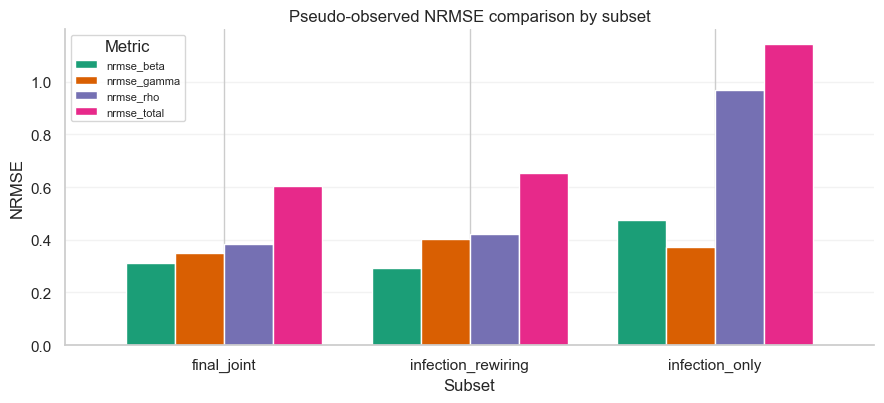

In [ ]:
# 5.3 pseudo-observed nrmse bar comparison
plot_df = subset_compare_df[[
    "subset", "nrmse_beta", "nrmse_gamma", "nrmse_rho", "nrmse_total"
]].set_index("subset")

ax = plot_df.plot(kind="bar", figsize=(9, 4.2), width=0.8, color=PALETTE[:4])
ax.set_xlabel("Subset")
ax.set_ylabel("NRMSE")
ax.set_title("Pseudo-observed NRMSE comparison by subset")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric", fontsize=8)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

Pseudo-observed recovery favors `final_joint` on aggregate error in this run; `infection_rewiring` is retained as a mechanistically interpretable comparator.

### 5.5 Decision

- `final_joint` is the primary subset for posterior reporting in this run.
- `infection_rewiring` remains a strong rewiring-aware benchmark.
- All three subsets are carried to real-data inference for transparency.
- Entropy screening is heuristic and does not guarantee minimum NRMSE across all seeds.

## 6. Rejection ABC on Real Observed Data

We run rejection ABC on the observed summary vector for each subset and compare posterior means, posterior spreads, and acceptance thresholds.

In [33]:
real_results = {}
rows = []

for label, idx in SUBSETS.items():
    acc, eps = abc_rejection(s_obs_norm, sims_norm, params_prior, idx, acceptance_rate=0.05)
    real_results[label] = acc
    m = acc.mean(axis=0)
    sd = acc.std(axis=0)

    rows.append({
        "subset": label,
        "n_stats": len(idx),
        "E_beta": m[0],
        "E_gamma": m[1],
        "E_rho": m[2],
        "std_beta": sd[0],
        "std_gamma": sd[1],
        "std_rho": sd[2],
        "threshold": eps,
        "n_accept": len(acc),
    })

real_summary_df = pd.DataFrame(rows)
display(real_summary_df)

,subset,n_stats,E_beta,E_gamma,E_rho,std_beta,std_gamma,std_rho,threshold,n_accept
0,infection_only,7,0.210134,0.087940,0.422362,0.073266,0.017583,0.227251,0.782065,5001
1,infection_rewiring,11,0.198154,0.097141,0.346155,0.057122,0.028357,0.099251,1.416768,5001
2,final_joint,16,0.207479,0.094143,0.347024,0.062399,0.021813,0.100676,1.528235,5001


Posterior centers for $(\beta,\gamma)$ are comparatively stable across subsets, while uncertainty in $\rho$ is more subset-dependent, consistent with transmission-rewiring confounding.

## 7. Quantifying Statistic Quality on Real Data

Without ground truth, real-data quality is summarized by:

1. Posterior contraction ratio relative to prior spread.
2. Approximate information gain (KL-style entropy reduction).

Contraction is the primary report metric; interpret jointly with predictive calibration rather than in isolation.

In [34]:
PRIOR_STD = params_prior.std(axis=0)
PARAM_LABELS = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_SUPPORTS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

contraction_rows = []
for label, accepted in real_results.items():
    post_std = accepted.std(axis=0)
    c = 1 - post_std / PRIOR_STD

    contraction_rows.append({
        "subset": label,
        "c_beta": c[0],
        "c_gamma": c[1],
        "c_rho": c[2],
        "std_beta": post_std[0],
        "std_gamma": post_std[1],
        "std_rho": post_std[2],
    })

contraction_df = pd.DataFrame(contraction_rows)
display(contraction_df)

,subset,c_beta,c_gamma,c_rho,std_beta,std_gamma,std_rho
0,infection_only,0.435996,0.661094,0.014524,0.073266,0.017583,0.227251
1,infection_rewiring,0.560271,0.453432,0.569597,0.057122,0.028357,0.099251
2,final_joint,0.519654,0.579573,0.563416,0.062399,0.021813,0.100676


### 7.1 Contraction Ratio Visualization

Bar heights summarize posterior learning intensity by parameter and subset.

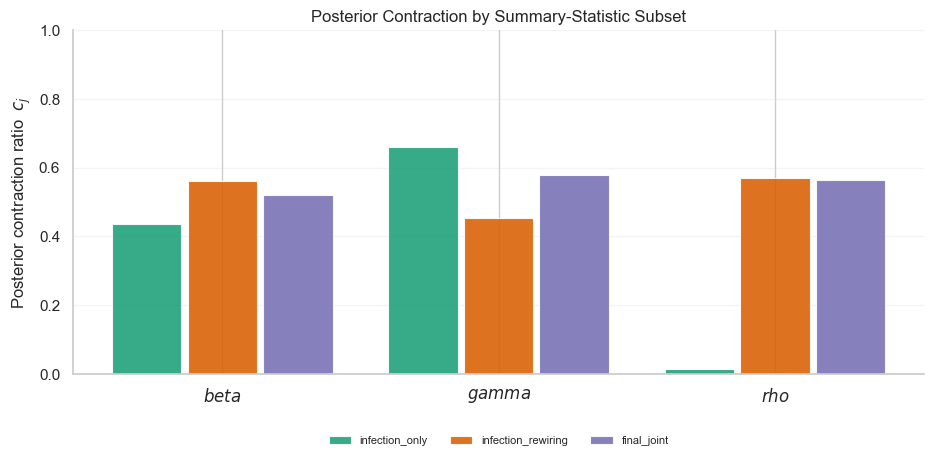

In [35]:
param_names_str = [r"$beta$", r"$gamma$", r"$rho$"]
subset_labels = contraction_df["subset"].tolist()
n_subsets = len(subset_labels)

x = np.arange(len(param_names_str), dtype=float)
group_width = 0.82
width = group_width / max(n_subsets, 1)
offsets = (np.arange(n_subsets) - (n_subsets - 1) / 2.0) * width

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for i, label in enumerate(subset_labels):
    row = contraction_df[contraction_df["subset"] == label].iloc[0]
    c = np.array([row["c_beta"], row["c_gamma"], row["c_rho"]], dtype=float)
    color = PALETTE[i % len(PALETTE)]
    ax.bar(
        x + offsets[i], c, width=width * 0.92,
        label=label,
        color=color, alpha=0.88, edgecolor="white", linewidth=0.8
    )

ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(param_names_str, fontsize=12)
ax.set_ylabel("Posterior contraction ratio  $c_j$")
ax.set_title("Posterior Contraction by Summary-Statistic Subset")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.20)
ax.legend(
    fontsize=8, ncol=min(3, n_subsets),
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15)
)

sns.despine()
plt.tight_layout()
plt.show()

Contraction is the real-data analogue of pseudo-observed error reduction; subset ranking should still be cross-checked against posterior predictive fit.

## 8. Posterior Visualization

### 8.1 Prior vs Posterior Marginals

Posterior concentration and displacement from the flat prior indicate information gain for each parameter.

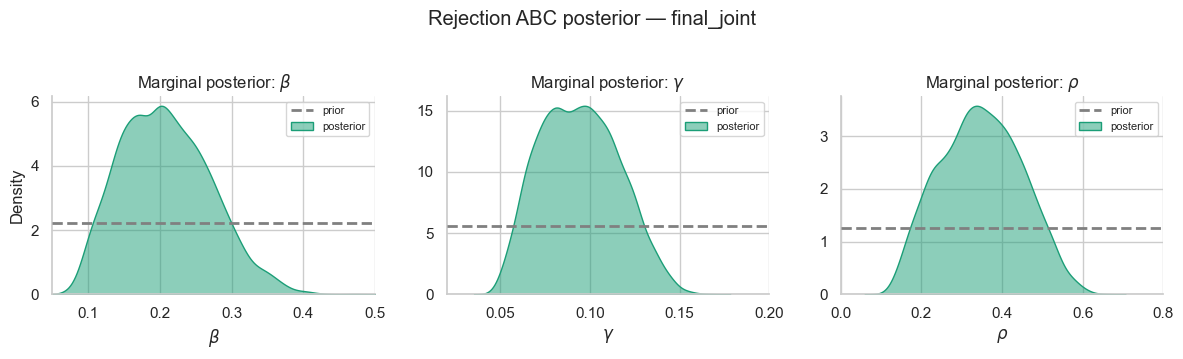

In [36]:
accepted_final = real_results["final_joint"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, (ax, label, bounds) in enumerate(zip(axes, PARAM_LABELS, PRIOR_SUPPORTS)):
    prior_height = 1.0 / (bounds[1] - bounds[0])
    ax.hlines(prior_height, bounds[0], bounds[1], colors="grey", lw=2,
            linestyles="--", label="prior", zorder=3)
    sns.kdeplot(accepted_final[:, j], ax=ax, color=PALETTE[0], fill=True,
                alpha=0.5, label="posterior", clip=bounds)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Density" if j == 0 else "")
    ax.set_xlim(bounds)
    ax.set_title(f"Marginal posterior: {label}")
    ax.legend(fontsize=8)

plt.suptitle("Rejection ABC posterior — final_joint", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

### 8.2 Pairwise Joint Posterior in $(\beta,\rho)$

The $(\beta,\rho)$ geometry is the primary identifiability diagnostic; elongated anti-diagonal structure indicates residual confounding.

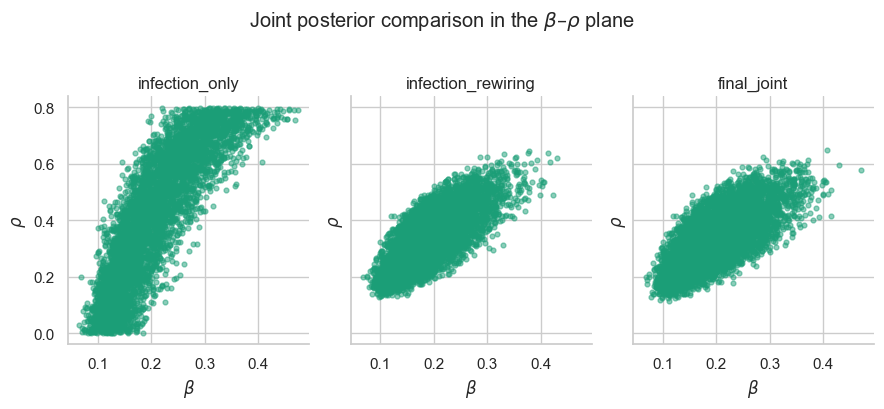

In [37]:
pairs = [(0, 3, r"$\beta$", r"$\rho$")]

compare_labels = ["infection_only", "infection_rewiring", "final_joint"]

fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)

for ax, label in zip(axes, compare_labels):
    accepted = real_results[label]
    ax.scatter(accepted[:, 0], accepted[:, 2], s=12, alpha=0.5, color=PALETTE[0])
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\rho$")
    ax.set_title(label)

plt.suptitle(r"Joint posterior comparison in the $\beta$–$\rho$ plane", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 9. Posterior Predictive Checks

### 9.1 Observed Incidence Reference

Simulator prevalence is mapped to an incidence proxy via first differences clipped at zero for trajectory-level comparison.

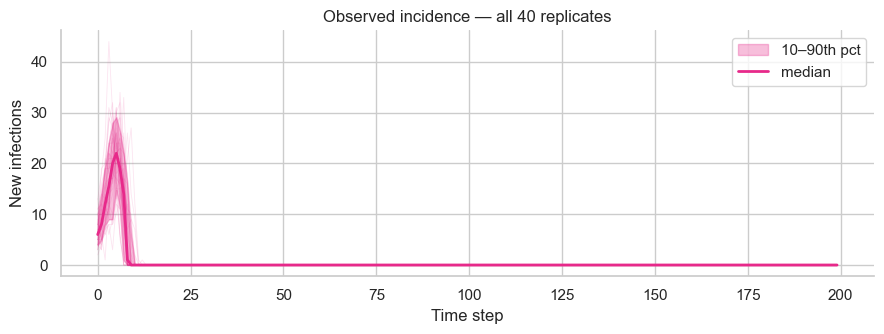

In [ ]:
def prevalence_to_incidence(infected_fraction, N=200):
    """Approximate incidence as max(ΔI, 0) * N."""
    delta = np.diff(infected_fraction)   # length T
    return np.clip(delta, 0, None) * N

# observed incidence by replicate
inf_wide_arr  = inf_wide.values                          # (201, 40)
obs_incidence = np.array([prevalence_to_incidence(inf_wide_arr[:, r])
                            for r in range(inf_wide_arr.shape[1])])   # (40, 200)

inc_lo  = np.quantile(obs_incidence, 0.10, axis=0)
inc_hi  = np.quantile(obs_incidence, 0.90, axis=0)
inc_med = np.quantile(obs_incidence, 0.50, axis=0)
t_inc   = np.arange(200)

fig, ax = plt.subplots(figsize=(9, 3.5))
for row in obs_incidence:
    ax.plot(t_inc, row, color=PALETTE[3], alpha=0.12, lw=0.6)
ax.fill_between(t_inc, inc_lo, inc_hi, color=PALETTE[3], alpha=0.30, label="10–90th pct")
ax.plot(t_inc, inc_med, color=PALETTE[3], lw=2, label="median")
ax.set(xlabel="Time step", ylabel="New infections", title="Observed incidence — all 40 replicates")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


### 9.2 Posterior Predictive Check: Prevalence and Incidence

Posterior draws from `final_joint` should cover observed median trends and central variability bands.

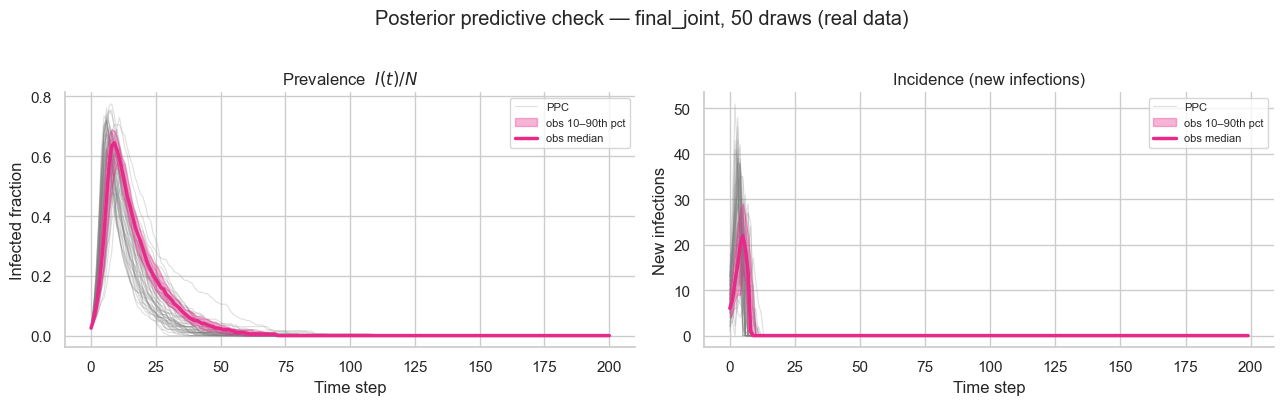

In [ ]:
N_PPC    = 50
rng_ppc  = np.random.default_rng(123)
accepted_final = real_results["final_joint"]
ppc_idx  = rng_ppc.choice(len(accepted_final), size=N_PPC, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (ax, title, transform) in enumerate(zip(
    axes,
    ["Prevalence  $I(t)/N$", "Incidence (new infections)"],
    [lambda x: x, prevalence_to_incidence]
)):
    # posterior predictive trajectories
    for k, pid in enumerate(ppc_idx):
        beta_k, gamma_k, rho_k = accepted_final[pid]
        inf_k, _, _ = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_ppc)
        y = transform(inf_k)
        ax.plot(np.arange(len(y)), y, color="grey", alpha=0.25, lw=0.8,
                label="PPC" if k == 0 else None)

    # observed median and percentile band
    if ax_idx == 0:
        lo  = inf_lo.values
        med = inf_med.values
        hi  = inf_hi.values
        t_obs = inf_wide.index.values
    else:
        lo, med, hi = inc_lo, inc_med, inc_hi
        t_obs = t_inc

    ax.fill_between(t_obs, lo, hi, color=PALETTE[3], alpha=0.35, zorder=4,
                    label="obs 10–90th pct")
    ax.plot(t_obs, med, color=PALETTE[3], lw=2.5, label="obs median", zorder=5)
    ax.set(xlabel="Time step", title=title)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Infected fraction")
axes[1].set_ylabel("New infections")
plt.suptitle("Posterior predictive check — final_joint, 50 draws (real data)", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()


### 9.3 Posterior Predictive Check: Final Degree Distribution

Degree-structure fit is especially informative for rewiring intensity ($\rho$) in the adaptive network.

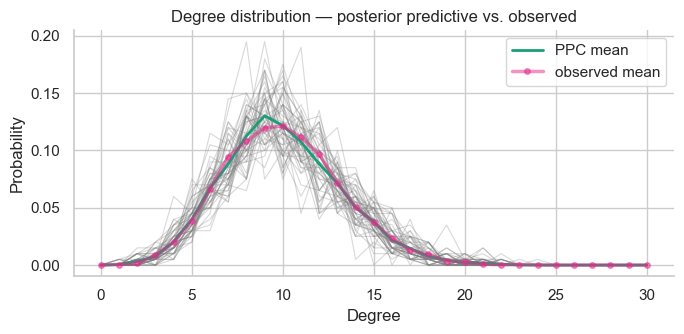

In [40]:
ppc_deg_stack = []
for pid in ppc_idx:
    beta_k, gamma_k, rho_k = accepted_final[pid]
    _, _, deg_k = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_ppc)
    ppc_deg_stack.append(deg_k / deg_k.sum())
ppc_deg_stack = np.array(ppc_deg_stack)   # (N_PPC, 31)

degrees = np.arange(31)
fig, ax = plt.subplots(figsize=(7, 3.5))

for row in ppc_deg_stack:
    ax.plot(degrees, row, color="grey", alpha=0.3, lw=0.8)
ax.plot(degrees, ppc_deg_stack.mean(axis=0), color=PALETTE[0], lw=2, label="PPC mean")
ax.plot(degrees, obs_deg_prob.values, color=PALETTE[3], lw=2.5, marker="o", ms=4,
        alpha=0.5, label="observed mean", zorder=5)

ax.set(xlabel="Degree", ylabel="Probability",
        title="Degree distribution — posterior predictive vs. observed")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


### 9.4 Comparison Diagrams (Observed vs Posterior Predictive)

Integrated prevalence, incidence, and degree diagnostics for compact reporting of calibration quality.

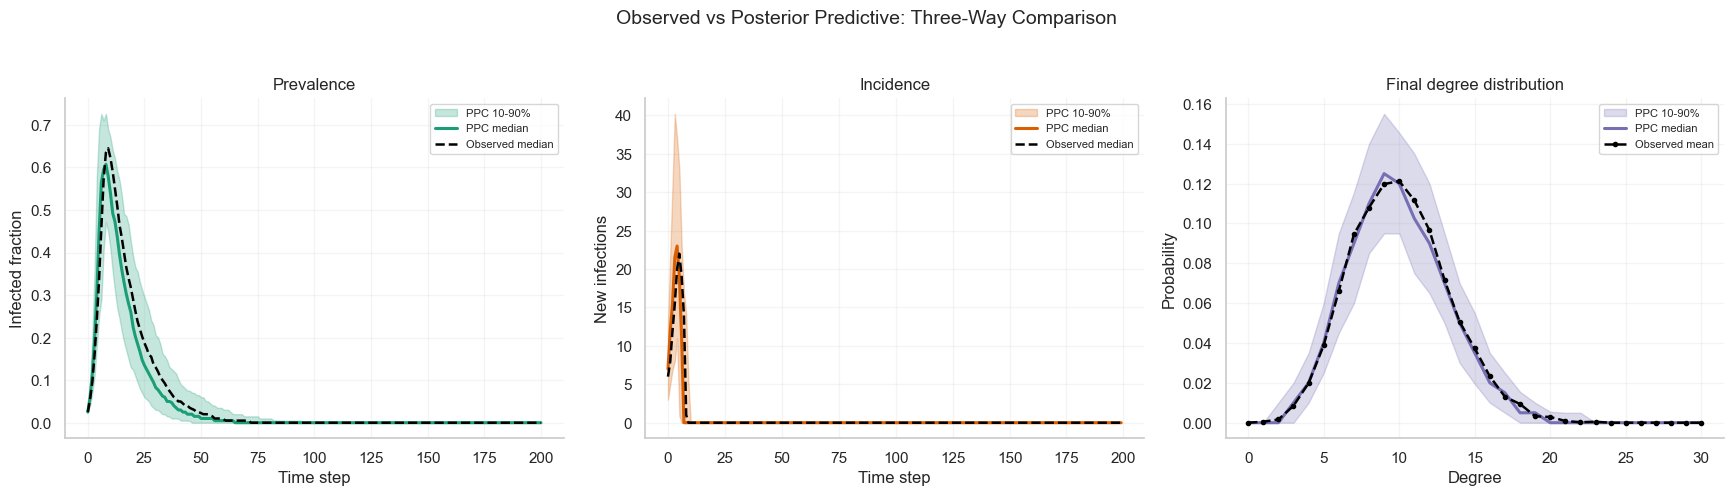

In [ ]:
# build observed-vs-ppc comparison diagrams
if "ppc_prev" not in globals() or "ppc_inc" not in globals() or "ppc_deg" not in globals():
    rng_eval = np.random.default_rng(321)
    n_eval = min(100, len(accepted_final))
    eval_idx = rng_eval.choice(len(accepted_final), size=n_eval, replace=False)

    ppc_prev = []
    ppc_inc = []
    ppc_deg = []
    for pid in eval_idx:
        beta_k, gamma_k, rho_k = accepted_final[pid]
        inf_k, _, deg_k = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_eval)
        ppc_prev.append(inf_k)
        ppc_inc.append(prevalence_to_incidence(inf_k))
        ppc_deg.append(deg_k / deg_k.sum())

    ppc_prev = np.asarray(ppc_prev, dtype=float)
    ppc_inc = np.asarray(ppc_inc, dtype=float)
    ppc_deg = np.asarray(ppc_deg, dtype=float)

# ppc central envelopes
ppc_prev_lo = np.quantile(ppc_prev, 0.10, axis=0)
ppc_prev_med = np.quantile(ppc_prev, 0.50, axis=0)
ppc_prev_hi = np.quantile(ppc_prev, 0.90, axis=0)

ppc_inc_lo = np.quantile(ppc_inc, 0.10, axis=0)
ppc_inc_med = np.quantile(ppc_inc, 0.50, axis=0)
ppc_inc_hi = np.quantile(ppc_inc, 0.90, axis=0)

ppc_deg_lo = np.quantile(ppc_deg, 0.10, axis=0)
ppc_deg_med = np.quantile(ppc_deg, 0.50, axis=0)
ppc_deg_hi = np.quantile(ppc_deg, 0.90, axis=0)

obs_prev_med = inf_med.values
obs_inc_med = inc_med
obs_deg = obs_deg_prob.values

# 1x3 diagnostic layout
fig, axes = plt.subplots(1, 3, figsize=(17.5, 4.8))

# (a) prevalence
ax = axes[0]
t_prev = np.arange(len(obs_prev_med))
ax.fill_between(t_prev, ppc_prev_lo, ppc_prev_hi, color=PALETTE[0], alpha=0.25, label="PPC 10-90%")
ax.plot(t_prev, ppc_prev_med, color=PALETTE[0], lw=2.2, label="PPC median")
ax.plot(t_prev, obs_prev_med, color="black", lw=1.8, ls="--", label="Observed median")
ax.set_title("Prevalence")
ax.set_xlabel("Time step")
ax.set_ylabel("Infected fraction")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# (b) incidence
ax = axes[1]
t_inc_local = np.arange(len(obs_inc_med))
ax.fill_between(t_inc_local, ppc_inc_lo, ppc_inc_hi, color=PALETTE[1], alpha=0.25, label="PPC 10-90%")
ax.plot(t_inc_local, ppc_inc_med, color=PALETTE[1], lw=2.2, label="PPC median")
ax.plot(t_inc_local, obs_inc_med, color="black", lw=1.8, ls="--", label="Observed median")
ax.set_title("Incidence")
ax.set_xlabel("Time step")
ax.set_ylabel("New infections")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# (c) final degree distribution
ax = axes[2]
deg_x = np.arange(len(obs_deg))
ax.fill_between(deg_x, ppc_deg_lo, ppc_deg_hi, color=PALETTE[2], alpha=0.25, label="PPC 10-90%")
ax.plot(deg_x, ppc_deg_med, color=PALETTE[2], lw=2.2, label="PPC median")
ax.plot(deg_x, obs_deg, color="black", lw=1.8, marker="o", ms=3, ls="--", label="Observed mean")
ax.set_title("Final degree distribution")
ax.set_xlabel("Degree")
ax.set_ylabel("Probability")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

plt.suptitle("Observed vs Posterior Predictive: Three-Way Comparison", y=1.03, fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()